# **1. Raw Data**

In [1]:
import json
import pandas as pd

## Bible

In [2]:
for bible_id, lang in [(293, "aym"), (2250, "aym"), (146, "spa"), (4278, "spa")]:

    with open(f"data/raw/bible/{lang}/{bible_id}.json", "r", encoding="utf-8") as file:
        data = json.load(file)

    num_verses = len(data)

    print(f"Number of verses for Bible Id = {bible_id} (lang: {lang}) --> {num_verses}")

Number of verses for Bible Id = 293 (lang: aym) --> 30816
Number of verses for Bible Id = 2250 (lang: aym) --> 30700
Number of verses for Bible Id = 146 (lang: spa) --> 31104
Number of verses for Bible Id = 4278 (lang: spa) --> 30720


## Book

In [3]:
df_book = pd.read_csv("data/raw/book/book.tsv", sep="\t")
print(f"Number of raw pairs --> {len(df_book)}")

Number of raw pairs --> 1907


# **2. Clean Data**

## Bible

In [4]:
df_clean_bible = pd.read_csv("data/clean/verses_aligned_clean.tsv", sep="\t")
print(f"Number of pairs in clean bibliblal corpus --> {len(df_clean_bible)}")

Number of pairs in clean bibliblal corpus --> 120904


In [5]:
for elem in ["train", "val", "test"]:
    df_set = pd.read_csv(f"data/splits/{elem}_bible.tsv", sep="\t")
    print(f"Number of pairs for [{elem}] --> {len(df_set)}")

Number of pairs for [train] --> 108823
Number of pairs for [val] --> 6048
Number of pairs for [test] --> 6033


## Book

In [6]:
df_clean_book = pd.read_csv("data/clean/book_clean.tsv", sep="\t")
print(f"Number of pairs in clean book corpus --> {len(df_clean_book)}")

Number of pairs in clean book corpus --> 1618


In [7]:
for elem in ["train", "val", "test"]:
    df_set = pd.read_csv(f"data/splits/{elem}_dialogue.tsv", sep="\t")
    print(f"Number of pairs for [{elem}] --> {len(df_set)}")

Number of pairs for [train] --> 1132
Number of pairs for [val] --> 242
Number of pairs for [test] --> 244


# **3. Plots**

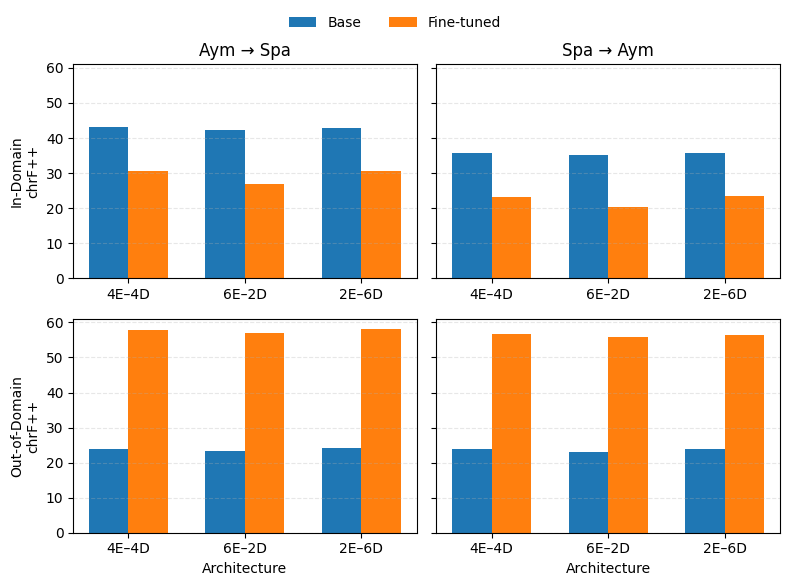

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Data: chrF++ scores from Table 1
# ============================================================

architectures = ["4E–4D", "6E–2D", "2E–6D"]

data = {
    "Aym → Spa": {
        "Base ID":        [43.16, 42.15, 42.77],
        "Fine-tuned ID":  [30.58, 26.73, 30.67],
        "Base OOD":       [23.92, 23.28, 24.25],
        "Fine-tuned OOD": [57.81, 56.87, 58.10],
    },

    "Spa → Aym": {
        "Base ID":        [35.80, 35.00, 35.59],
        "Fine-tuned ID":  [23.22, 20.16, 23.48],
        "Base OOD":       [24.01, 22.99, 23.87],
        "Fine-tuned OOD": [56.74, 55.82, 56.41],
    }
}

# ============================================================
# Figure: 2 rows × 2 columns
#
# Row 1: In-Domain
# Row 2: Out-of-Domain
#
# Column 1: Aym → Spa
# Column 2: Spa → Aym
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 6),
    sharey=True
)

x = np.arange(len(architectures))
width = 0.34

# ------------------------------------------------------------
# Plot each panel
# ------------------------------------------------------------

for col, direction in enumerate(["Aym → Spa", "Spa → Aym"]):

    values = data[direction]

    # ========================================================
    # In-Domain
    # ========================================================

    ax = axes[0, col]

    base_id = values["Base ID"]
    ft_id = values["Fine-tuned ID"]

    ax.bar(
        x - width / 2,
        base_id,
        width,
        label="Base"
    )

    ax.bar(
        x + width / 2,
        ft_id,
        width,
        label="Fine-tuned"
    )

    ax.set_title(direction, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(architectures)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # ========================================================
    # Out-of-Domain
    # ========================================================

    ax = axes[1, col]

    base_ood = values["Base OOD"]
    ft_ood = values["Fine-tuned OOD"]

    ax.bar(
        x - width / 2,
        base_ood,
        width,
        label="Base"
    )

    ax.bar(
        x + width / 2,
        ft_ood,
        width,
        label="Fine-tuned"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(architectures)

    ax.set_xlabel("Architecture")

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

# ============================================================
# Row labels
# ============================================================

axes[0, 0].set_ylabel("In-Domain\nchrF++")
axes[1, 0].set_ylabel("Out-of-Domain\nchrF++")

# ============================================================
# Common legend at the top
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False
)

# No main title
# ============================================================

plt.tight_layout(rect=[0, 0, 1, 0.94])

# ============================================================
# Save as vector PDF for Overleaf
# ============================================================
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True)

plt.savefig(
    output_dir / "architecture_chrf_2x2.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()